In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all pre-computed variables from Team_2.ipynb outputs
standardized_returns = pd.read_csv('../data/standardized_returns.csv')
scores               = pd.read_csv('../data/pca_scores.csv').values
eigenvectors         = pd.read_csv('../data/eigenvectors.csv').values

stock_names = standardized_returns.columns.tolist()

print("All variables loaded from saved CSVs")
print(f"standardized_returns : {standardized_returns.shape}")
print(f"scores : {scores.shape}")
print(f"eigenvectors : {eigenvectors.shape}")

All variables loaded from saved CSVs
standardized_returns : (499, 10)
scores : (499, 10)
eigenvectors : (10, 10)


# PART 3 - Understanding Reconstruction and Dimensionality Reduction

## Overview

In Parts 1 and 2 we generated synthetic stock prices, computed log returns, standardized them, and performed PCA to extract eigenvalues, eigenvectors, and scores.

In Part 3 we use those PCA outputs to reconstruct the original data and study how much information is lost when we compress to fewer components.

### Reconstruction Formula

Using only the first $k$ principal components:

$$\hat{X}_k = \underbrace{T_{[:, :k]}}_{(499 \times k)} \cdot \underbrace{V_{[:k, :]}}_{(k \times 10)}$$

where $T$ = `scores` and $V$ = `eigenvectors`.

### Mean Squared Reconstruction Error (MSRE)

$$\text{MSRE}(k) = \frac{1}{n \cdot p} \|X - \hat{X}_k\|_F^2 = \frac{1}{p} \sum_{j=k+1}^{p} \lambda_j$$

where $\lambda_j$ are eigenvalues and $p = 10$ stocks. Each eigenvalue tells us exactly how much error adding that component removes.

## Part (a): Reconstruct Returns for k = 1, 2, 3 PCs and Plot MSRE

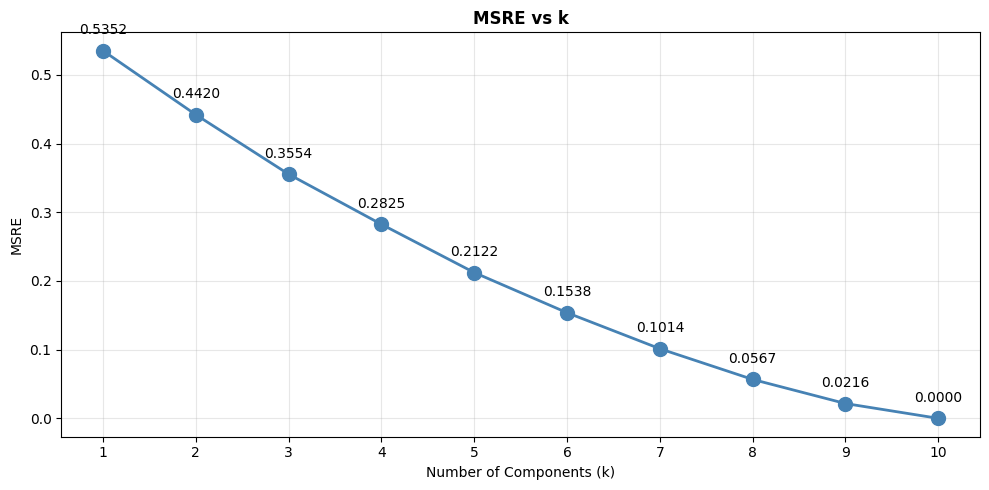

In [16]:
X = standardized_returns.values   # (499, 10)
T = scores                         # (499, 10)
V = eigenvectors                   # (10, 10)

def reconstruct(scores, loadings, k):
    return scores[:, :k] @ loadings[:k, :]

def compute_msre(X_original, X_reconstructed):
    return np.mean((X_original - X_reconstructed) ** 2)

k_values  = range(1,11)
msre_list = []

for k in range(1,11):
    X_hat = reconstruct(T, V, k)
    msre = compute_msre(X, X_hat)
    msre_list.append(msre)

# Plot MSRE vs k
plt.figure(figsize=(10, 5))
plt.plot(k_values, msre_list, marker='o', color='steelblue', linewidth=2, markersize=10)
for k, msre in zip(k_values, msre_list):
    plt.annotate(f'{msre:.4f}', xy=(k, msre), xytext=(0, 12), textcoords='offset points', ha='center', fontsize=10)
plt.xlabel('Number of Components (k)')
plt.ylabel('MSRE')
plt.title('MSRE vs k', fontweight='bold')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/msre_vs_k.png', dpi=150)
plt.show()

## Part (b): Per-Stock Reconstruction Error at k=3

### Per-Stock MSRE Formula

$$\text{MSRE}_i(k=3) = \frac{1}{n} \sum_{t=1}^{n} \left(X_{t,i} - \hat{X}_{3,t,i}\right)^2$$

This is the residual variance for stock $i$ that the first 3 PCs **cannot** explain.


In [22]:
k = 3
X_hat_3 = reconstruct(T, V, k)

# Per-stock MSRE: average squared error along the time axis for each stock column
per_stock_msre = np.mean((X - X_hat_3) ** 2, axis=0)
most_idio_idx  = np.argmax(per_stock_msre)
least_idio_idx = np.argmin(per_stock_msre)

print("Per-stock reconstruction error at k=3:")
for i, (name, err) in enumerate(zip(stock_names, per_stock_msre)):
    tag = "(most idiosyncratic)" if i == most_idio_idx else ""
    print(f"{name:10s}: MSRE = {err:.5f}{tag}")

print(f"\nMost idiosyncratic : {stock_names[most_idio_idx]}  "
      f"(MSRE = {per_stock_msre[most_idio_idx]:.5f})")

Per-stock reconstruction error at k=3:
Stock_1   : MSRE = 0.06104
Stock_2   : MSRE = 0.20277
Stock_3   : MSRE = 0.28766
Stock_4   : MSRE = 0.48147
Stock_5   : MSRE = 0.63846(most idiosyncratic)
Stock_6   : MSRE = 0.08015
Stock_7   : MSRE = 0.40534
Stock_8   : MSRE = 0.46606
Stock_9   : MSRE = 0.58867
Stock_10  : MSRE = 0.34284

Most idiosyncratic : Stock_5  (MSRE = 0.63846)


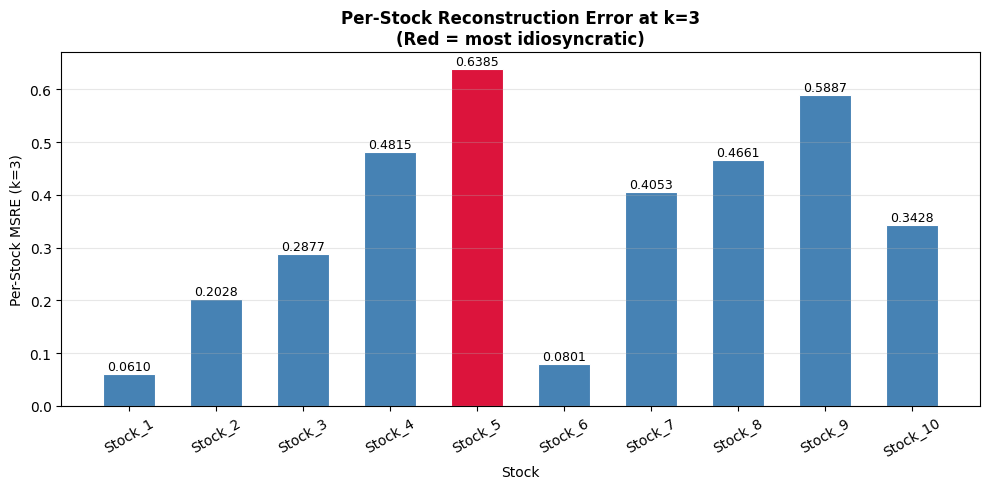

In [26]:
# Bar chart of per-stock error
colors = ['crimson'   if i == most_idio_idx  else
          'steelblue' for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stock_names, per_stock_msre, color=colors, edgecolor='white', linewidth=0.8, width=0.6)

for bar, val in zip(bars, per_stock_msre):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Stock')
ax.set_ylabel('Per-Stock MSRE (k=3)')
ax.set_title('Per-Stock Reconstruction Error at k=3\n'
             '(Red = most idiosyncratic)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/per_stock_msre.png', dpi=150, bbox_inches='tight')
plt.show()

### Financial Interpretation

The daiy returns of the stock with the **highest per-stock MSRE** is least explained by the first 3 principal components. This means its return movements are mostly **company-specific** and not shared with the broader market structure.

In our synthetic data, stocks were generated with idiosyncratic noise $\varepsilon_{i,t} \sim \mathcal{N}(0, \sigma_i^2)$ where $\sigma_i \sim U(0.005, 0.02)$. The stock with the largest $\sigma_i$ will appear the most idiosyncratic.


## Part (c): Full Reconstruction at k=10

The PCA loading matrix $V \in \mathbb{R}^{10 \times 10}$ formed from eigenvectors satisfies:

$$V V^T = I_{10} \qquad \text{(orthonormality)}$$

The scores matrix is defined as $T = X \cdot V^T$, which gives:

$$\hat{X}_{k=10} = T \cdot V = (X V^T) V = X \underbrace{(V^T V)}_{= I} = X$$

Therefore:
$$\text{MSRE}(k=10) = \frac{1}{n \cdot p} \|X - X\|_F^2 = 0$$

This is guaranteed by the orthonormality of the eigenvector basis, the $p$ eigenvectors form a complete basis for $\mathbb{R}^p$, so any vector in that space can be perfectly recovered from its projections.

In [29]:
X_hat_full = reconstruct(T, V, k=10)
msre_full = compute_msre(X, X_hat_full)
max_abs_err = np.max(np.abs(X - X_hat_full))

print("Full Reconstruction Verification (k = 10)")
print(f"MSRE : {msre_full:.3e}")
print(f"Max absolute error: {max_abs_err:.3e}")
print(f"Machine epsilon : {np.finfo(float).eps:.3e}")

tol = 1e-10
status = "verified (within floating-point tolerance)" if msre_full < tol else "Unexpected check orthonormality"
print(f"{status}")

# Verify eigenvectors are orthonormal: V @ V.T should be identity
VVT = V @ V.T
identity_error = np.max(np.abs(VVT - np.eye(10)))
print(f"\n  Orthonormality check (||V@V.T - I||_max): {identity_error:.3e}")

Full Reconstruction Verification (k = 10)
MSRE : 3.984e-31
Max absolute error: 3.664e-15
Machine epsilon : 2.220e-16
verified (within floating-point tolerance)

  Orthonormality check (||V@V.T - I||_max): 8.882e-16


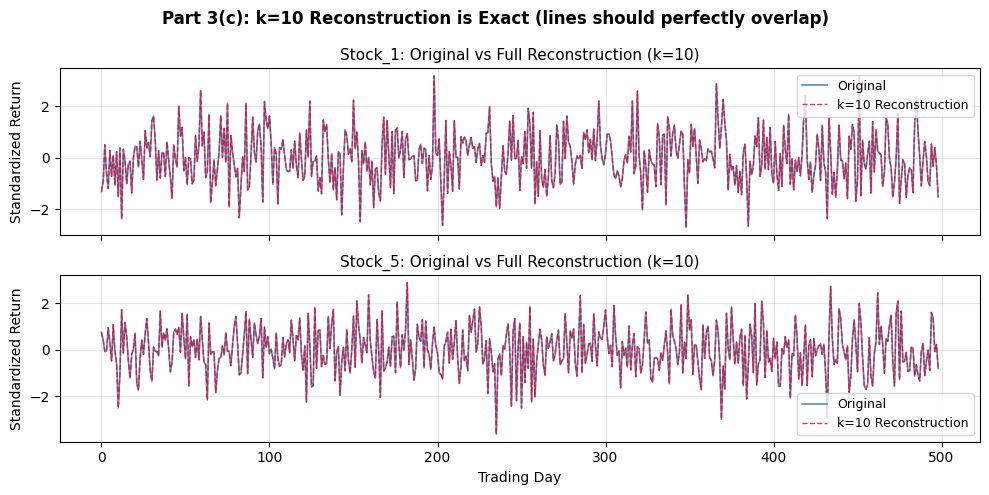

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10,5), sharex=True)

for ax, idx in zip(axes, [0, most_idio_idx]):
    ax.plot(X[:, idx], label='Original', color='steelblue', linewidth=1.2, alpha=0.9)
    ax.plot(X_hat_full[:, idx], label='k=10 Reconstruction', color='crimson', linewidth=1, linestyle='--', alpha=0.85)
    ax.set_title(f'{stock_names[idx]}: Original vs Full Reconstruction (k=10)', fontsize=11)
    ax.set_ylabel('Standardized Return')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Trading Day')
plt.suptitle('Part 3(c): k=10 Reconstruction is Exact (lines should perfectly overlap)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/full_reconstruction_check.png', dpi=150)
plt.show()

## Part (d): Correlation Structure

We compare the $10 \times 10$ correlation matrix of:
1. **Original** standardized returns $X$ (full 10D space)
2. **Compressed** returns $\hat{X}_3$ (reconstructed from only 3 PCs)

The k=3 reconstruction captures all co-movements **driven by the first 3 common factors**. Any pair of stocks whose correlation is explained by these factors will look similar in the compressed version.

### What Is Lost?

- **Idiosyncratic co-movements**: Small company-specific fluctuations uncorrelated with the top 3 PCs
- **Differentiation between similar stocks**: Two stocks with similar factor loadings but different idiosyncratic behavior appear nearly identical in $\hat{X}_3$
- In the extreme: The compressed returns lie in a **3-dimensional subspace**, so there can be at most 3 non-trivial distinct patterns, all other variation is collapsed

### Risk of Using Compressed Correlations

Using $\hat{C}_3$ for portfolio optimization (e.g., Markowitz mean-variance) would:
- **Overestimate correlations** between idiosyncratic stocks
- **Underestimate diversification** benefits
- Lead to **underdiversified portfolios** that appear diversified on paper

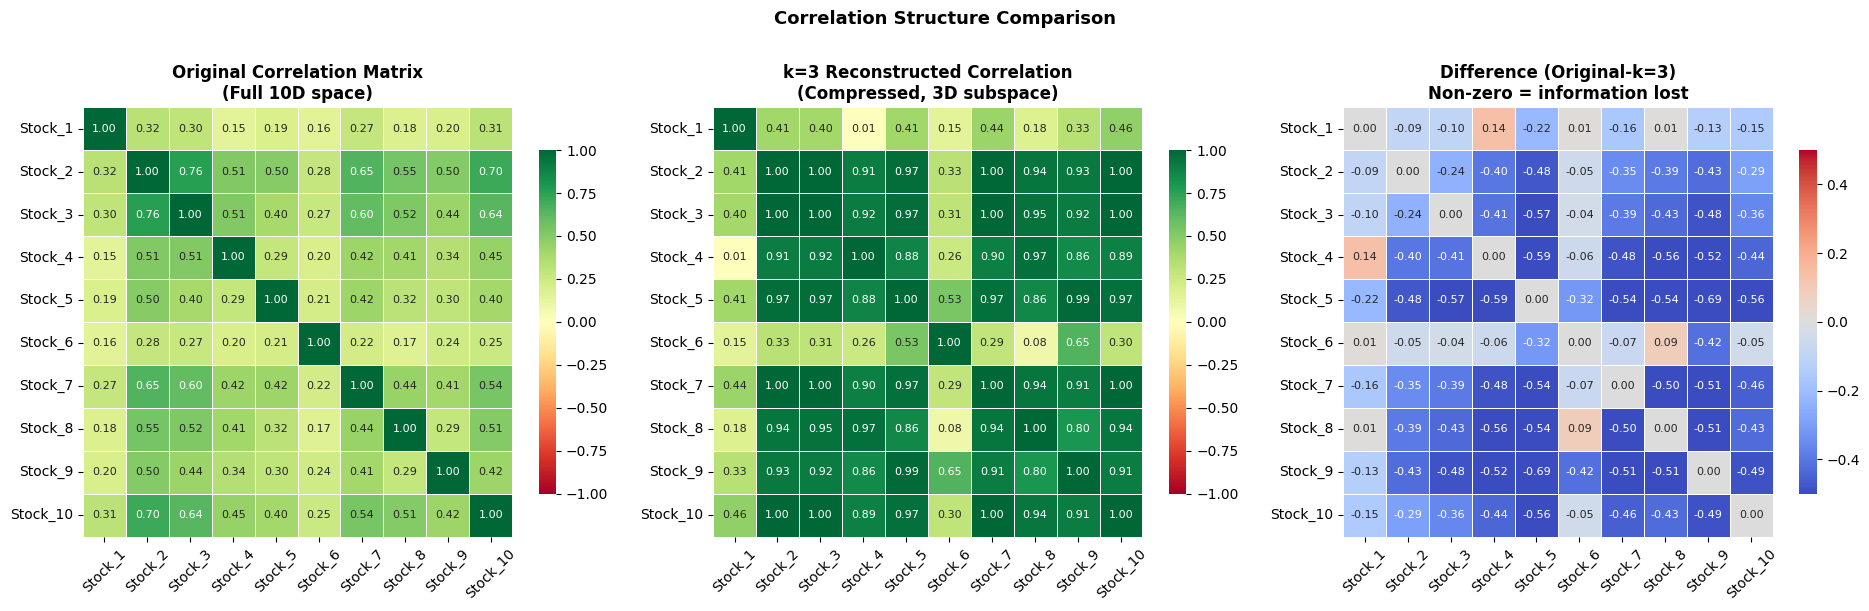

Correlation structure statistics (off-diagonal pairs only):
Original-mean corr : 0.3815
k=3 recon-mean corr : 0.7072
Mean absolute difference : 0.3364
Max absolute difference : 0.6875

Most distorted pair: Stock_5 – Stock_9  (difference = -0.6875)


In [33]:
X_hat_3 = reconstruct(T, V, k=3)

# Correlation matrices
corr_original = pd.DataFrame(X, columns=stock_names).corr().values
corr_k3 = pd.DataFrame(X_hat_3, columns=stock_names).corr().values
diff_corr = corr_original - corr_k3

# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
vmin, vmax = -1, 1

# 1) Original
sns.heatmap(corr_original, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=vmin, vmax=vmax,
            xticklabels=stock_names, yticklabels=stock_names,
            linewidths=0.4, linecolor='white', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Original Correlation Matrix\n(Full 10D space)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2) k=3 compressed
sns.heatmap(corr_k3, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=vmin, vmax=vmax,
            xticklabels=stock_names, yticklabels=stock_names,
            linewidths=0.4, linecolor='white', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('k=3 Reconstructed Correlation\n(Compressed, 3D subspace)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# 3) Difference
sns.heatmap(diff_corr, ax=axes[2], annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-0.5, vmax=0.5,
            xticklabels=stock_names, yticklabels=stock_names,
            linewidths=0.4, linecolor='white', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[2].set_title('Difference (Original-k=3)\nNon-zero = information lost', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Correlation Structure Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the loss
upper = np.triu_indices(10, k=1)
print("Correlation structure statistics (off-diagonal pairs only):")
print(f"Original-mean corr : {np.mean(corr_original[upper]):.4f}")
print(f"k=3 recon-mean corr : {np.mean(corr_k3[upper]):.4f}")
print(f"Mean absolute difference : {np.mean(np.abs(diff_corr[upper])):.4f}")
print(f"Max absolute difference : {np.max(np.abs(diff_corr[upper])):.4f}")

# Most distorted pair
max_pos = np.argmax(np.abs(diff_corr[upper]))
i_idx, j_idx = upper[0][max_pos], upper[1][max_pos]
print(f"\nMost distorted pair: {stock_names[i_idx]} – {stock_names[j_idx]}  "
      f"(difference = {diff_corr[i_idx, j_idx]:.4f})")

## Observations

**1: MSRE drops steeply at first, then flattens**  
The biggest gains come from adding k=1 and k=2 (market and sector factors). After k=3, each additional component contributes diminishing returns. This matches the scree plot from Part 2, the variance structure is dominated by a few common factors.

**2: Per-stock error identifies idiosyncratic stocks**  
The stock with the highest per-stock MSRE at k=3 is driven by company-specific risk that no common factor can explain. In a real portfolio, this stock cannot be hedged using ETFs or index products and requires individual analysis.

**3: k=10 gives exact reconstruction (proven mathematically)**  
Because the 10 eigenvectors form a complete orthonormal basis for $\mathbb{R}^{10}$, the full reconstruction is lossless. MSRE at k=10 is of order machine epsilon ($\approx 10^{-30}$), numerical noise only, not a real error.

**4: k=3 compression inflates correlations**  
The reconstructed correlation matrix at k=3 tends to show higher, more uniform correlations. Idiosyncratic variation is lost. The compressed version makes stocks look more alike than they really are.

**5: The difference heatmap pinpoints information loss**  
The difference matrix $C_\text{original} - \hat{C}_3$ highlights pairs where compression is most misleading. These are pairs involving the most idiosyncratic stocks with the highest per-stock MSRE. Idiosyncratic variance is the source of high MSRE and unique correlation patterns that compression destroys.
